In [2]:
import polars as pl
import os
import json
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]  # Fast_Data_Discovery
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

exp_path = NOTEBOOK_DIR / 'logs'
base_scores = pl.read_csv(PROJECT_ROOT / 'experiments' / 'base_tables' / 'base_simple_scores.csv').rename({'': 'table'})
aug_scores = pl.read_csv(exp_path / 'simple_results.csv').rename({'': 'experiment'})

exp_dir = os.listdir(exp_path)
runtime_res = {}
for exp in exp_dir:
    if not os.path.isdir(exp_path / exp):
        continue
    comb_log = exp_path / exp / f'{exp}.log'
    with open(comb_log) as f:
        lines = f.readlines()
    for i in range(len(lines)):
        lines[i] = json.loads(lines[i])
    df = pl.from_records(lines, orient='col')
    runtime = df.select(pl.col('runtime').sum()).to_series()[0]
    runtime_res[exp] = runtime
runtime_df = pl.from_dicts([{'experiment': k, 'runtime': v} for k, v in runtime_res.items()])
aug_scores = aug_scores.join(runtime_df, left_on='experiment', right_on='experiment', how='left')
aug_scores = aug_scores.with_columns(
    pl.col('experiment').str.split('_').list.to_struct(upper_bound=3, fields=['lake', 'table', 'task', 'tol']).struct.unnest()
)
aug_scores = aug_scores.join(base_scores, on='table', how='left', suffix='_base')

aug_scores = aug_scores.with_columns((pl.col('rmse_base').fill_null(0) + pl.col('f1_weighted_base').fill_null(0)).round(3).alias('score_base'))
aug_scores = aug_scores.with_columns((pl.col('rmse').fill_null(0) + pl.col('f1_weighted').fill_null(0)).round(3).alias('score'))
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('rmse').is_not_null())
    .then(pl.lit('rmse'))
    .otherwise(pl.lit('f1'))
    .alias('metric')
)
# Create base rows for each unique (lake, table) combination
base_rows = (
    aug_scores
    .unique(subset=['lake', 'table'])
    .with_columns([
        pl.lit('base').alias('algorithm'),
        pl.col('score_base').alias('score'),
        pl.col('rmse_base').alias('rmse'),
        pl.col('f1_weighted_base').alias('f1'),
        pl.lit(0.0).alias('runtime'),
        (pl.col('lake') + '_' + pl.col('table') + '_base').alias('experiment')
    ])
    .select(aug_scores.columns)
)
aug_scores = pl.concat([aug_scores, base_rows])
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('table') == 'pageviews')
    .then((pl.col('score')/1e6).round(3))
    .otherwise(pl.col('score'))
    .alias('score')
)

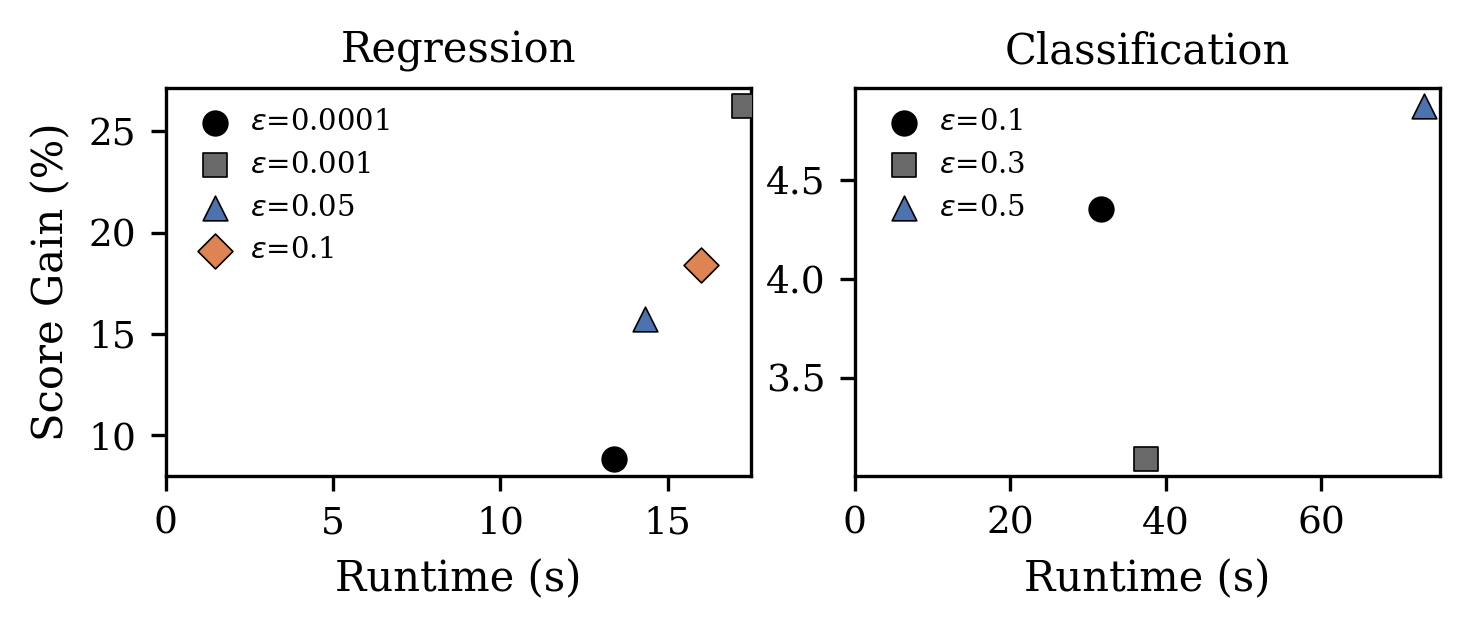

In [4]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
import plots_style
plots_style.apply_style()

# Filter out base rows
data = aug_scores.filter(pl.col('tol').is_not_null())

# Relative improvement (direction-aware)
data = data.with_columns(
    pl.when(pl.col('metric') == 'rmse')
    .then((pl.col('score_base') - pl.col('score')) / pl.col('score_base'))
    .otherwise((pl.col('score') - pl.col('score_base')) / pl.col('score_base'))
    .alias('rel_improvement')
)

reg_data = data.filter(pl.col('task') == 'regression')
clf_data = data.filter(pl.col('task') == 'classification')

reg_agg = reg_data.group_by('tol').agg([
    pl.col('rel_improvement').mean().alias('mean_improvement'),
    pl.col('runtime').mean().alias('mean_runtime'),
]).with_columns(pl.col('tol').cast(pl.Float64)).sort('tol')

clf_agg = clf_data.group_by('tol').agg([
    pl.col('rel_improvement').mean().alias('mean_improvement'),
    pl.col('runtime').mean().alias('mean_runtime'),
]).with_columns(pl.col('tol').cast(pl.Float64)).sort('tol')

reg_markers = ['o', 's', '^', 'D']
clf_markers = ['o', 's', '^']
colors_reg = ['black', 'dimgray', '#4c72b0', '#dd8452']
colors_clf = ['black', 'dimgray', '#4c72b0']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4.8, 2.0))

# Regression
for i, row in enumerate(reg_agg.iter_rows(named=True)):
    ax1.scatter(row['mean_runtime'], row['mean_improvement'] * 100,
                marker=reg_markers[i], color=colors_reg[i],
                label=f'$\\epsilon$={row["tol"]}', s=35, zorder=3,
                edgecolors='black', linewidths=0.4)
ax1.set_xlim(left=0)
ax1.set_xlabel('Runtime (s)')
ax1.set_ylabel('Score Gain (%)')
ax1.set_title('Regression')
ax1.legend(fontsize=7, handletextpad=0.2, borderpad=0.2, loc='best')

# Classification
for i, row in enumerate(clf_agg.iter_rows(named=True)):
    ax2.scatter(row['mean_runtime'], row['mean_improvement'] * 100,
                marker=clf_markers[i], color=colors_clf[i],
                label=f'$\\epsilon$={row["tol"]}', s=35, zorder=3,
                edgecolors='black', linewidths=0.4)
ax2.set_xlim(left=0)
ax2.set_xlabel('Runtime (s)')
ax2.set_title('Classification')
ax2.legend(fontsize=7, handletextpad=0.2, borderpad=0.2, loc='best')

plt.tight_layout(pad=0.3)
plt.savefig(PAPER_ROOT / 'figures' / 'tol_ablation.pdf')
plt.show()